# LLaVA (Large Language and Vision Assistant) 사용 예제

LLaVA는 **CLIP 비전 인코더**와 **LLM(Llama/Vicuna)** 을 연결한 오픈소스 멀티모달 대화 모델입니다.
BLIP처럼 캡션을 생성할 수 있을 뿐 아니라, **지시 따르기(instruction following)**, **추론**, **다중 턴 대화**까지 수행할 수 있습니다.(영어 전용)

논문: https://arxiv.org/abs/2304.08485 (Visual Instruction Tuning)

이 노트북에서 다루는 내용:
1. LLaVA-1.5 모델 로드 (`llava-hf/llava-1.5-7b-hf`)
2. **이미지 설명** — 단일 턴 질의응답
3. **Visual Question Answering (VQA)** — 다양한 질문에 답변
4. **다중 턴 대화** — 이전 맥락을 이어가며 질문
5. **지시 따르기** — 세부 묘사, 개수 세기 등
6. **배치 추론** — 여러 이미지를 한꺼번에 질의
7. **레거시 프롬프트 형식** — `USER: <image> ... ASSISTANT:` 직접 사용
8. **BLIP vs BLIP-2 vs LLaVA 비교 요약**


## 1. 환경 설정

터미널에서 의존성을 설치합니다.

```bash
pip install -r requirements.txt
```

```
torch>=2.0.0
torchvision>=0.15.0
transformers>=4.40.0
accelerate>=0.27.0
pillow>=10.0.0
matplotlib>=3.8.0
requests>=2.31.0
jupyter>=1.0.0
ipykernel>=6.29.0
```

> **GPU 메모리 안내**: `llava-1.5-7b-hf`는 fp16 기준 약 **14GB VRAM**이 필요합니다.
> GPU가 없거나 메모리가 부족하면 CPU에서도 실행 가능하지만 매우 느립니다.
> 최초 실행 시 Hugging Face Hub에서 약 **13GB**를 다운로드합니다.


In [3]:
# LLaVA GPU 로드(device_map="auto")에 필요 — 노트북 커널과 동일한 Python에 설치됨
%pip install -q accelerate>=0.27.0


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import torch
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from transformers import AutoProcessor, LlavaForConditionalGeneration


def setup_korean_font():
    """matplotlib 한글 폰트 설정 (Windows/Mac/Linux)"""
    for font in ("Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans KR"):
        if font in {f.name for f in fm.fontManager.ttflist}:
            plt.rcParams["font.family"] = font
            break
    else:
        print("한글 폰트를 찾지 못했습니다. 제목 한글이 □로 표시될 수 있습니다.")
    plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지


setup_korean_font()

# GPU 사용 가능 시 cuda, 아니면 cpu
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32  # GPU는 VRAM 절약을 위해 fp16
print(f"사용 디바이스: {device}")
print(f"연산 dtype: {dtype}")
print(f"matplotlib 폰트: {plt.rcParams['font.family']}")


사용 디바이스: cuda
연산 dtype: torch.float16
matplotlib 폰트: ['Malgun Gothic']


## 2. LLaVA 모델 로드

| 모델 | 파라미터 | 특징 |
|------|----------|------|
| `llava-hf/llava-1.5-7b-hf` | 7B | 가장 널리 쓰이는 기본 모델 (이 노트북 기본값) |
| `llava-hf/llava-1.5-13b-hf` | 13B | 더 높은 품질, VRAM 24GB+ 권장 |

LLaVA-1.5는 Vicuna-7B + CLIP-ViT-L/336px 구조이며, 대화 형식은 `USER: <image>\n{질문} ASSISTANT:` 입니다.
`transformers>=4.49`부터는 `processor.apply_chat_template()`으로 프롬프트를 자동 구성할 수 있습니다.


In [ ]:
MODEL_ID = "llava-hf/llava-1.5-7b-hf"

# device_map 사용 여부 판단 — accelerate 미설치 시 수동 .to(device)로 대체
try:
    import accelerate  # noqa: F401
    has_accelerate = True
except ImportError:
    has_accelerate = False
    print("accelerate 미설치: device_map 대신 model.to(device)를 사용합니다.")

load_kwargs = {
    "torch_dtype": dtype,
    "low_cpu_mem_usage": True,  # RAM 절약형 로딩
}
if device == "cuda" and has_accelerate:
    load_kwargs["device_map"] = "auto"  # 가용 GPU에 자동 배치

# Hugging Face Hub에서 모델·전처리기 로드 (최초 실행 시 캐시에 다운로드, 약 13GB)
model = LlavaForConditionalGeneration.from_pretrained(MODEL_ID, **load_kwargs)
processor = AutoProcessor.from_pretrained(MODEL_ID)  # 이미지·텍스트 통합 전처리기

if device == "cpu" or not has_accelerate:
    model = model.to(device)

model.eval()  # 추론 모드: dropout 등 비활성화

print(f"모델 로드 완료: {MODEL_ID}")
print(f"모델 디바이스: {next(model.parameters()).device}")
# PC에서 다운로드 약 22분 소요 (약 13GB 크기)


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

c:\Users\storm\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\storm\.cache\huggingface\hub\models--llava-hf--llava-1.5-7b-hf. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors.index.json:   0%|          | 0.00/70.1k [00:00<?, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

...

tokenizer.json:   0%|          | 0.00/3.62M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/41.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

모델 로드 완료: llava-hf/llava-1.5-7b-hf
모델 디바이스: cuda:0


## 3. 샘플 이미지 준비

MS COCO val2017 CDN URL을 사용합니다. 전체 데이터셋을 다운로드할 필요가 없습니다.
로컬 이미지를 쓰려면 `Image.open("경로/이미지.jpg")` 또는 `load_image_from_url("https://...")`를 사용하면 됩니다.


URL: http://images.cocodataset.org/val2017/000000543581.jpg
COCO image_id=543581, category=dog, size=(640, 427)
COCO 참고 캡션: A dog is sitting on the couch in a living room.


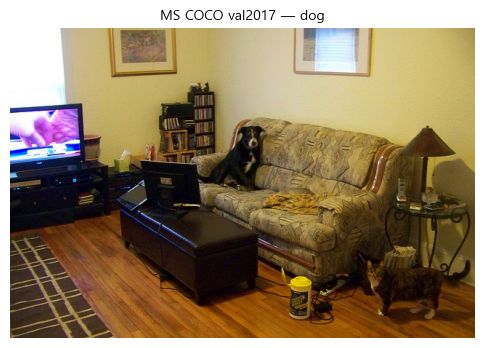

In [3]:
from dataclasses import dataclass

# COCO 공식 CDN — val2017 이미지를 개별 URL로 제공
COCO_IMAGE_BASE = "http://images.cocodataset.org/val2017/"

# MS COCO val2017 — 예제용 샘플만 URL로 지정 (전체 데이터셋 다운로드 불필요)
# file_name: COCO val2017 파일명, captions: 사람이 작성한 참고 캡션 (LLaVA 결과 비교용)
COCO_SAMPLE_URLS: dict[str, dict] = {
    "dog": {
        "file_name": "000000543581.jpg",
        "image_id": 543581,
        "captions": [
            "A dog is sitting on the couch in a living room.",
            "A cute black dog sitting on the couch.",
        ],
    },
    "cat": {
        "file_name": "000000039769.jpg",
        "image_id": 39769,
        "captions": [
            "There are two cats laying down with two remotes",
            "Two cats sleeping with a remote control near each of them.",
        ],
    },
    "car": {
        "file_name": "000000527220.jpg",
        "image_id": 527220,
        "captions": [
            "A red car next to a gas station sign and parked blue and silver motorcycles.",
            "A red Ferrari at a gas station showing the gas prices and three mopeds",
        ],
    },
    "airplane": {
        "file_name": "000000001761.jpg",
        "image_id": 1761,
        "captions": [
            "Two planes flying in the sky over a bridge.",
            "Two planes fly over a bridge in Sydney, Australia, with the Sydney Opera House in the background.",
        ],
    },
}

COCO_SAMPLE_CATEGORIES = list(COCO_SAMPLE_URLS.keys())
_url_image_cache: dict[str, Image.Image] = {}  # 동일 URL 재요청 방지


@dataclass
class CocoSample:
    """COCO URL 샘플 1건 — 이미지 + 메타데이터"""
    image: Image.Image
    image_id: int
    category: str
    url: str
    captions: list[str]


def load_image_from_url(url: str) -> Image.Image:
    """URL에서 이미지 로드 (캐시 + User-Agent)"""
    if url in _url_image_cache:
        return _url_image_cache[url].copy()

    headers = {"User-Agent": "LLaVA-Example-Notebook/1.0 (learning example)"}
    response = requests.get(url, timeout=30, headers=headers)
    response.raise_for_status()
    image = Image.open(BytesIO(response.content)).convert("RGB")
    _url_image_cache[url] = image
    return image.copy()


def load_coco_sample_meta(category: str) -> CocoSample:
    """COCO val2017 URL에서 샘플 이미지 + 참고 캡션 반환"""
    if category not in COCO_SAMPLE_URLS:
        raise ValueError(
            f"등록되지 않은 카테고리 '{category}'. "
            f"사용 가능: {', '.join(COCO_SAMPLE_CATEGORIES)}"
        )
    meta = COCO_SAMPLE_URLS[category]
    url = COCO_IMAGE_BASE + meta["file_name"]
    image = load_image_from_url(url)
    return CocoSample(
        image=image,
        image_id=meta["image_id"],
        category=category,
        url=url,
        captions=meta["captions"],
    )


def load_coco_sample(category: str) -> Image.Image:
    """지정 COCO 카테고리 샘플 이미지만 반환"""
    return load_coco_sample_meta(category).image


def load_coco_samples(categories: list[str]) -> list[CocoSample]:
    """여러 카테고리 샘플을 한꺼번에 로드"""
    return [load_coco_sample_meta(cat) for cat in categories]


def show_image(image: Image.Image, title: str = ""):
    """이미지 1장 표시 (고해상도 COCO용 figsize=6)"""
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    if title:
        plt.title(title, fontsize=10)
    plt.show()


# 예제용 강아지 이미지 로드 — 이후 섹션에서 `image`, `sample` 변수 재사용
sample = load_coco_sample_meta("dog")
image = sample.image
print(f"URL: {sample.url}")
print(f"COCO image_id={sample.image_id}, category={sample.category}, size={image.size}")
print(f"COCO 참고 캡션: {sample.captions[0]}")
show_image(image, f"MS COCO val2017 — {sample.category}")


## 4. 추론 헬퍼 함수

`apply_chat_template`으로 대화 형식을 맞추고, 생성된 텍스트에서 ASSISTANT 응답만 추출합니다.


In [4]:
def extract_assistant_response(decoded: str) -> str:
    """디코딩 결과에서 ASSISTANT 응답 부분만 반환"""
    if "ASSISTANT:" in decoded:
        return decoded.split("ASSISTANT:")[-1].strip()
    return decoded.strip()


def _move_inputs_to_model(inputs: dict) -> dict:
    """텐서를 모델 디바이스·dtype에 맞게 이동"""
    model_device = next(model.parameters()).device
    moved = {}
    for key, value in inputs.items():
        if not hasattr(value, "to"):
            moved[key] = value
            continue
        if key == "pixel_values":
            moved[key] = value.to(model_device, dtype=dtype)  # 비전 입력은 fp16/fp32 맞춤
        else:
            moved[key] = value.to(model_device)
    return moved


def ask_llava(
    question: str,
    *,
    image: Image.Image | None = None,
    image_url: str | None = None,
    conversation: list[dict] | None = None,
    max_new_tokens: int = 128,
    do_sample: bool = False,
    temperature: float = 0.2,
) -> str:
    """LLaVA에 질문하고 ASSISTANT 응답 문자열을 반환.

    - `conversation`이 주어지면 다중 턴 대화로 처리
    - 그렇지 않으면 단일 턴: image_url 또는 image + question
    """
    if conversation is None:
        # 단일 턴: user 메시지에 이미지 + 텍스트 질문 구성
        content = []
        if image_url:
            content.append({"type": "image", "url": image_url})
        elif image is not None:
            content.append({"type": "image", "image": image})
        else:
            raise ValueError("image 또는 image_url 중 하나는 필요합니다.")
        content.append({"type": "text", "text": question})
        conversation = [{"role": "user", "content": content}]

    # LLaVA-1.5 대화 형식(USER/ASSISTANT)으로 프롬프트 구성 + 토큰화
    inputs = processor.apply_chat_template(
        conversation,
        add_generation_prompt=True,  # 마지막에 "ASSISTANT:" 추가
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    )
    inputs = _move_inputs_to_model(inputs)

    generate_kwargs = {"max_new_tokens": max_new_tokens}
    if do_sample:
        generate_kwargs.update({"do_sample": True, "temperature": temperature})

    with torch.no_grad():
        output_ids = model.generate(**inputs, **generate_kwargs)

    decoded = processor.batch_decode(output_ids, skip_special_tokens=True)[0]
    return extract_assistant_response(decoded)


print("헬퍼 함수 준비 완료")


헬퍼 함수 준비 완료


## 5. 이미지 설명 (단일 턴)

가장 기본적인 사용법입니다. 이미지에 대해 자유 형식으로 질문합니다.


질문: Describe this image in detail.
LLaVA 답변: The image features a cozy living room with a comfortable couch and a TV placed on a stand. A dog is sitting on the couch, while a cat is standing nearby, both appearing to be watching the TV. 

The room also contains a collection of books, with several books scattered around the space. A cup can be seen placed on a surface, and a remote control is located close to the couch. The overall atmosphere of the room is warm and inviting, with the pets enjoying their time together.
COCO 참고 캡션: A dog is sitting on the couch in a living room.


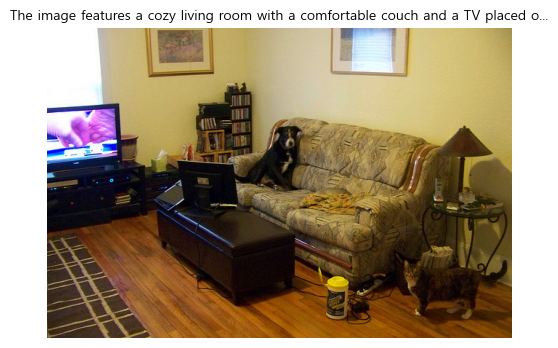

In [ ]:
question = "Describe this image in detail."
answer = ask_llava(question, image_url=sample.url, max_new_tokens=200)

print(f"질문: {question}")
print(f"LLaVA 답변: {answer}")
print(f"COCO 참고 캡션: {sample.captions[0]}")
show_image(image, answer[:80] + ("..." if len(answer) > 80 else ""))
# RTX 3060 : 약 4.5분 소요


## 6. Visual Question Answering (VQA)

같은 이미지에 여러 질문을 던져 세부 정보를 확인합니다.


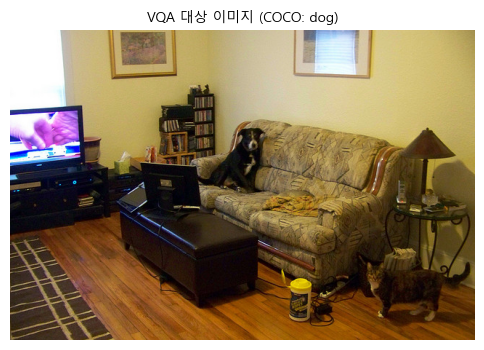

VQA 결과:
  Q: What animal is in this image?
  A: There is a dog in this image.

  Q: Where is the animal sitting?
  A: The animal is sitting on a couch in a living room.

  Q: Is the dog alone in the image?
  A: No, the dog is not alone in the image. There is a cat sitting next to the dog on the couch.

  Q: What is the main color of the dog?
  A: The main color of the dog is black and white.



In [ ]:
# BLIP VQA와 마찬가지로 LLaVA도 영어 질문에 최적화
questions = [
    "What animal is in this image?",
    "Where is the animal sitting?",
    "Is the dog alone in the image?",
    "What is the main color of the dog?",
]

show_image(image, f"VQA 대상 이미지 (COCO: {sample.category})")
print("VQA 결과:")
for q in questions:
    ans = ask_llava(q, image_url=sample.url, max_new_tokens=64)
    print(f"  Q: {q}")
    print(f"  A: {ans}")
    print()
# RTX 3060 : 약 2.5분 소요


## 7. 다중 턴 대화

첫 턴에서 이미지를 보여준 뒤, 이후 턴에서는 텍스트만으로 후속 질문을 이어갑니다.
LLaVA는 Vicuna 기반이므로 대화 맥락을 유지합니다.


In [ ]:
# 첫 턴: 이미지 + 질문 (이후 턴은 텍스트만으로 맥락 유지)
conversation = [
    {
        "role": "user",
        "content": [
            {"type": "image", "url": sample.url},
            {"type": "text", "text": "Briefly describe what you see in this image."},
        ],
    },
]

first_answer = ask_llava("", conversation=conversation, max_new_tokens=80)
print(f"[턴 1] A: {first_answer}")

# assistant 응답을 히스토리에 추가한 뒤 후속 질문
conversation.extend([
    {"role": "assistant", "content": [{"type": "text", "text": first_answer}]},
    {"role": "user", "content": [{"type": "text", "text": "What is the dog doing?"}]},
])

second_answer = ask_llava("", conversation=conversation, max_new_tokens=64)
print(f"[턴 2] Q: What is the dog doing?")
print(f"[턴 2] A: {second_answer}")

# 세 번째 턴: 추론이 필요한 개방형 질문
conversation.extend([
    {"role": "assistant", "content": [{"type": "text", "text": second_answer}]},
    {"role": "user", "content": [{"type": "text", "text": "Would this be a good photo for a pet adoption website? Why?"}]},
])

third_answer = ask_llava("", conversation=conversation, max_new_tokens=120)
print(f"[턴 3] Q: Would this be a good photo for a pet adoption website? Why?")
print(f"[턴 3] A: {third_answer}")
# RTX 3060 : 약 9분 소요


[턴 1] A: The image features a cozy living room with a couch and a chair. A dog is sitting on the couch, while a cat is standing nearby. There is a TV on the left side of the room, and a laptop is placed on the couch. 

The room also contains a collection of books, with several books scattered around the space. A cup can be seen on
[턴 2] Q: What is the dog doing?
[턴 2] A: The dog is sitting on the couch, likely enjoying the comfortable environment of the living room.
[턴 3] Q: Would this be a good photo for a pet adoption website? Why?
[턴 3] A: Yes, this photo would be a good choice for a pet adoption website. The image showcases a harmonious and relaxed atmosphere, with both a dog and a cat sharing the living room comfortably. This suggests that the pets are well-adjusted and likely get along with each other, which is an important factor for potential adopters. 

Additionally, the presence of a laptop and a TV in the room indicates that the pets are allowed to roam freely and engage in 

## 8. 지시 따르기 — 다른 이미지로 추론 테스트

고양이 이미지로 **개수 세기**, **객체 나열** 등 구조화된 지시를 수행합니다.


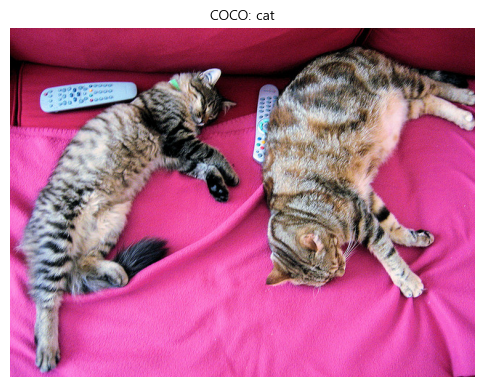

지시: List every object you can identify in this image.
응답: In the image, there are two cats lying on a pink couch. One cat is located on the left side of the couch, while the other cat is on the right side. There are also two remote controls in the scene, one near the left cat and the other near the right cat. Additionally, there is a TV remote control placed on the couch, closer to the left cat.
------------------------------------------------------------
지시: How many cats are visible? Answer with a number only.
응답: 2
------------------------------------------------------------
지시: Are there any electronic devices in the image? If yes, name them.
응답: Yes, there are electronic devices in the image. There are two remote controls, one near each cat.
------------------------------------------------------------


In [ ]:
cat_sample = load_coco_sample_meta("cat")
show_image(cat_sample.image, f"COCO: {cat_sample.category}")

# 구조화된 지시 — 객체 나열, 개수 세기, 특정 카테고리 탐지
tasks = [
    ("List every object you can identify in this image.", 120),
    ("How many cats are visible? Answer with a number only.", 16),
    ("Are there any electronic devices in the image? If yes, name them.", 80),
]

for prompt, max_tokens in tasks:
    result = ask_llava(prompt, image_url=cat_sample.url, max_new_tokens=max_tokens)
    print(f"지시: {prompt}")
    print(f"응답: {result}")
    print("-" * 60)
# RTX 3060 : 약 4.5분 소요


## 9. 배치 추론

여러 이미지에 동일한 질문을 한꺼번에 적용합니다.
배치 생성 시 `padding_side="left"`를 설정하면 결과가 더 정확합니다.


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


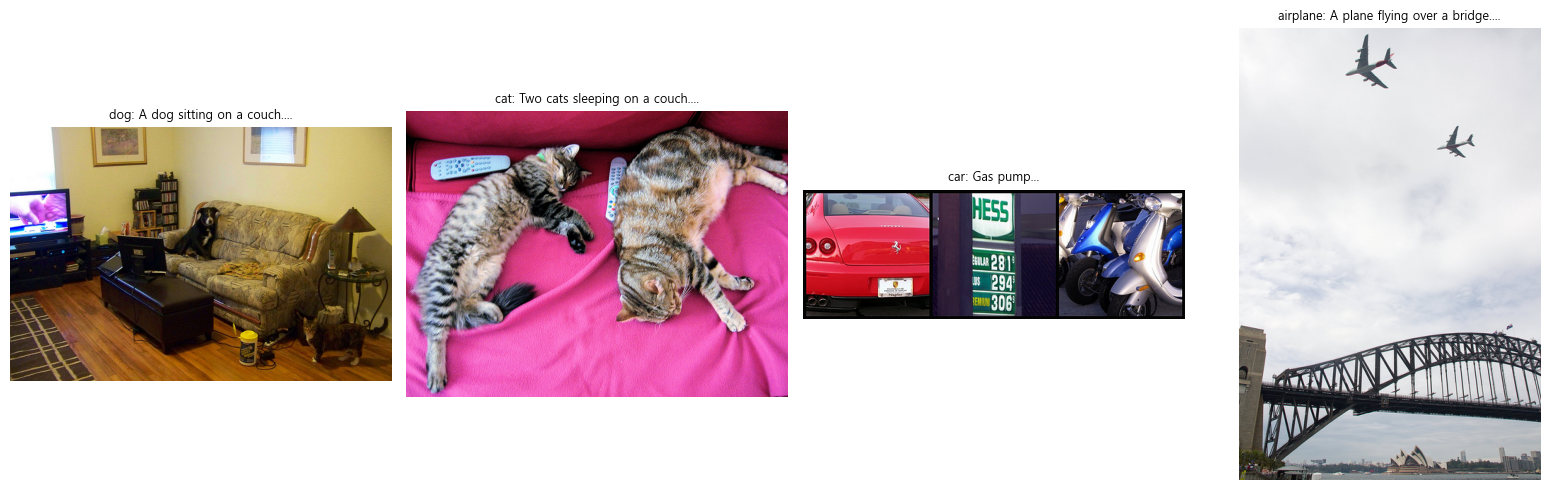

공통 질문: What is the main subject of this image? Answer in one short sentence.
  [dog] A dog sitting on a couch.
  [cat] Two cats sleeping on a couch.
  [car] Gas pump
  [airplane] A plane flying over a bridge.


In [ ]:
# 배치 생성 시 왼쪽 패딩이 디코더 정확도에 유리 (transformers 권장)
processor.tokenizer.padding_side = "left"

batch_samples = load_coco_samples(["dog", "cat", "car", "airplane"])
question = "What is the main subject of this image? Answer in one short sentence."

# 이미지마다 동일 질문의 대화 리스트 구성
conversations = []
for s in batch_samples:
    conversations.append([
        {
            "role": "user",
            "content": [
                {"type": "image", "url": s.url},
                {"type": "text", "text": question},
            ],
        }
    ])

inputs = processor.apply_chat_template(
    conversations,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    padding=True,  # 배치 내 시퀀스 길이 맞춤
    return_tensors="pt",
)
inputs = _move_inputs_to_model(inputs)

with torch.no_grad():
    output_ids = model.generate(**inputs, max_new_tokens=64)

decoded_batch = processor.batch_decode(output_ids, skip_special_tokens=True)

# 4장 이미지 + 답변을 한눈에 비교
fig, axes = plt.subplots(1, len(batch_samples), figsize=(16, 5))
if len(batch_samples) == 1:
    axes = [axes]

for ax, s, decoded in zip(axes, batch_samples, decoded_batch):
    ax.imshow(s.image)
    ax.axis("off")
    answer = extract_assistant_response(decoded)
    ax.set_title(f"{s.category}: {answer[:50]}...", fontsize=9)

plt.tight_layout()
plt.show()

print(f"공통 질문: {question}")
for s, decoded in zip(batch_samples, decoded_batch):
    print(f"  [{s.category}] {extract_assistant_response(decoded)}")

# RTX 3060 : 약 36초 소요


## 10. 레거시 프롬프트 형식

LLaVA-1.5 원본 형식인 `USER: <image>\n{질문} ASSISTANT:` 를 직접 사용하는 방법입니다.
`apply_chat_template` 없이 `processor(text=..., images=...)`로도 동작합니다.


In [10]:
# LLaVA-1.5 원본 프롬프트 형식 — apply_chat_template 없이 직접 사용
prompt = "USER: <image>\nWhat breed might this dog be? ASSISTANT:"

inputs = processor(text=prompt, images=image, return_tensors="pt")
inputs = _move_inputs_to_model(inputs)

with torch.no_grad():
    output_ids = model.generate(**inputs, max_new_tokens=64)

decoded = processor.batch_decode(output_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]
legacy_answer = extract_assistant_response(decoded)

print(f"프롬프트: {prompt}")
print(f"응답: {legacy_answer}")
# RTX 3060 : 약 2.5분 소요


프롬프트: USER: <image>
What breed might this dog be? ASSISTANT:
응답: Based on the image, the dog is likely a Border Collie. This breed is known for its intelligence, agility, and ability to work well with humans. The dog is sitting on a couch next to a laptop, which suggests that it is comfortable in a domestic setting and might be trained to perform tasks


## 11. BLIP vs BLIP-2 vs LLaVA 비교 요약

| 항목 | BLIP (02번) | BLIP-2 (03번) | LLaVA (이 노트북) |
|------|-------------|----------------|-------------------|
| **핵심 구조** | ViT + BERT 디코더 | ViT + Q-Former + frozen LLM | CLIP-ViT + Vicuna LLM |
| **LLM 백본** | BERT (소형) | Flan-T5-XL | Vicuna-7B |
| **질문 언어** | △ (영어 중심) | ✓ (다국어 입력 가능) | △ (영어 중심) |
| **응답 언어** | 영어 | **영어** | 영어 |
| **모델 크기** | ~990M (base) | ~4B (instructblip-flan-t5-xl) | ~7B |
| **VRAM** | ~2GB | ~8~10GB (fp16) | ~14GB (fp16) |
| **대화** | 단일 턴 Q→A | 단일 턴 지시·VQA | 다중 턴 맥락 유지 |
| **적합 용도** | 빠른 캡션·ITM·VQA | 영어 캡션·지시 따르기 | 복잡한 추론·대화형 AI |

**선택 가이드**
- 빠르고 가벼운 **캡션·매칭** → BLIP (`02_blip_image_captioning.ipynb`)
- **한국어 질문 + 영어 답변** VQA → BLIP-2 + Flan-T5 (`03_blip2_FlanT5.ipynb`)
- **한국어 답변**이 필요 → 별도 번역 파이프라인 또는 Qwen2-VL 등 다국어 VLM
- **복잡한 추론·다중 턴 대화** → LLaVA (이 노트북)
- **분류·검색·유사도** → CLIP (`01_clip_example.ipynb`)
